#DeepSeek-OCR
Testing DeepSeek-OCR for PDF to Markdown conversion.

In [1]:
# Install dependencies
!pip install -q torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121
!pip install -q transformers==4.46.3 tokenizers==0.20.3 einops addict easydict pillow
!pip install -q pymupdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 60.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 71.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 105.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 49.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 114.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 21.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 46.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Load model

In [2]:
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

import torch
import os
from transformers import AutoModel, AutoTokenizer

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

MODEL_NAME = "deepseek-ai/DeepSeek-OCR"

print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Try flash_attention_2, fallback to eager if not available
try:
    model = AutoModel.from_pretrained(
        MODEL_NAME,
        _attn_implementation='flash_attention_2',
        trust_remote_code=True,
        use_safetensors=True
    )
    print("Using flash_attention_2")
except Exception as e:
    print(f"Flash attention not available, using eager")
    model = AutoModel.from_pretrained(
        MODEL_NAME,
        _attn_implementation='eager',
        trust_remote_code=True,
        use_safetensors=True
    )

model = model.eval().cuda().to(torch.bfloat16)
print(f"Model loaded on {next(model.parameters()).device}")

Loading deepseek-ai/DeepSeek-OCR...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-000001.safetensors:   0%|          | 0.00/6.67G [00:00<?, ?B/s]

Flash attention not available, using eager


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at deepseek-ai/DeepSeek-OCR and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on cuda:0


## Load PDF

In [ ]:
try:
    from google.colab import files
    print("Upload your PDF file:")
    uploaded = files.upload()
    pdf_path = list(uploaded.keys())[0]
    print(f"PDF uploaded: {pdf_path}")
    
except ImportError:
    pdf_path = "data/benchmark"  
    print(f"Running locally, using: {pdf_path}")

Upload your PDF file:


Saving FlexQube.pdf to FlexQube.pdf
PDF uploaded: FlexQube.pdf


## PDF to Images

In [4]:
import fitz  # PyMuPDF
from PIL import Image

def pdf_to_images(pdf_path: str, dpi: int = 200) -> list[Image.Image]:
    """Convert PDF pages to PIL Images."""
    doc = fitz.open(pdf_path)
    images = []

    zoom = dpi / 72
    matrix = fitz.Matrix(zoom, zoom)

    for page_num in range(len(doc)):
        page = doc[page_num]
        pix = page.get_pixmap(matrix=matrix)
        img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
        images.append(img)
        print(f"  Page {page_num + 1}: {pix.width}x{pix.height}px")

    doc.close()
    return images

print(f"Converting {pdf_path} to images...")
pages = pdf_to_images(pdf_path, dpi=200)
print(f"Converted {len(pages)} pages")

Converting FlexQube.pdf to images...
  Page 1: 1654x2339px
  Page 2: 3308x2339px
  Page 3: 3308x2339px
  Page 4: 3308x2339px
  Page 5: 3308x2339px
  Page 6: 3308x2339px
  Page 7: 3308x2339px
  Page 8: 3308x2339px
  Page 9: 3308x2339px
  Page 10: 3308x2339px
  Page 11: 3308x2339px
  Page 12: 3308x2339px
  Page 13: 3308x2339px
  Page 14: 3308x2339px
  Page 15: 3308x2339px
  Page 16: 3308x2339px
  Page 17: 3308x2339px
  Page 18: 3308x2339px
  Page 19: 3308x2339px
  Page 20: 3308x2339px
  Page 21: 3308x2339px
  Page 22: 3308x2339px
  Page 23: 3308x2339px
  Page 24: 3308x2339px
  Page 25: 3308x2339px
  Page 26: 3308x2339px
  Page 27: 3308x2339px
  Page 28: 3308x2339px
  Page 29: 3308x2339px
  Page 30: 3308x2339px
  Page 31: 3308x2339px
  Page 32: 3308x2339px
  Page 33: 3308x2339px
  Page 34: 3308x2339px
  Page 35: 3308x2339px
  Page 36: 3308x2339px
  Page 37: 3308x2339px
  Page 38: 3308x2339px
  Page 39: 3308x2339px
  Page 40: 3308x2339px
  Page 41: 3308x2339px
  Page 42: 3308x2339px
  Page

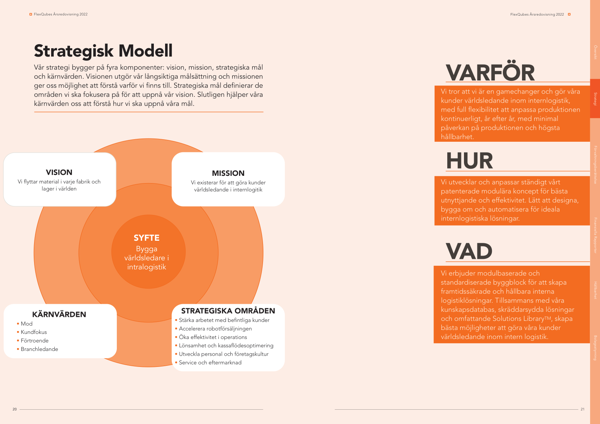

In [6]:
# Page preview
from IPython.display import display

preview = pages[10].copy()
preview.thumbnail((600, 800))
display(preview)

## Run OCR

In [7]:
import sys
from io import StringIO

PROMPTS = {
    "document_to_markdown": "<image>\n<|grounding|>Convert the document to markdown.",
    "free_ocr": "<image>\nFree OCR.",
    "ocr_image": "<image>\n<|grounding|>OCR this image.",
}

def ocr_single_image(image: Image.Image, prompt_type: str = "document_to_markdown") -> str:
    """Run OCR on a single image."""
    prompt = PROMPTS.get(prompt_type, PROMPTS["document_to_markdown"])

    if image.mode != "RGB":
        image = image.convert("RGB")

    temp_path = "/tmp/temp_ocr_image.png"
    image.save(temp_path)

    # Capture stdout
    old_stdout = sys.stdout
    sys.stdout = captured_output = StringIO()

    with torch.no_grad():
        model.infer(
            tokenizer,
            prompt=prompt,
            image_file=temp_path,
            output_path="/tmp",
            base_size=1024,
            image_size=640,
            crop_mode=True,
            save_results=False
        )

    sys.stdout = old_stdout
    raw_output = captured_output.getvalue()

    # Parse output - extract text only
    lines = []
    for line in raw_output.split('\n'):
        if '<|ref|>' in line or '<|det|>' in line:
            continue
        if line.startswith('=') or line.startswith('BASE:') or line.startswith('PATCHES:'):
            continue
        if 'torch.Size' in line or 'attention' in line.lower():
            continue
        if line.strip():
            lines.append(line.strip())

    return '\n'.join(lines)


def ocr_pdf_pages(pages: list[Image.Image], prompt_type: str = "document_to_markdown") -> str:
    """Run OCR on all pages."""
    results = []

    for i, page in enumerate(pages):
        print(f"Processing page {i + 1}/{len(pages)}...", flush=True)
        text = ocr_single_image(page, prompt_type)
        results.append(text)

    return "\n\n---\n\n".join(results)

In [8]:
print("Running DeepSeek-OCR...")
ocr_result = ocr_pdf_pages(pages)
print(f"Done! ({len(ocr_result):,} chars)")

Running DeepSeek-OCR...
Processing page 1/68...


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.
`get_max_cache()` is deprecated for all Cache classes. Use `get_max_cache_shape()` instead. Calling `get_max_cache()` will raise error from v4.48
The attention layers in this model are transitioning from computing the RoPE embeddings internally through `position_ids` (2D tensor with the indexes of the tokens), to using externally computed `position_embeddings` (Tuple of tensors, containing cos and si

Processing page 2/68...


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Processing page 3/68...


...

Processing page 67/68...


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Processing page 68/68...


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Done! (205,325 chars)


## Save Results

In [9]:
result_path = "deepseek_ocr_output.md"
with open(result_path, "w", encoding="utf-8") as f:
    f.write(ocr_result)

print(f"Saved to: {result_path}")
files.download(result_path)

Saved to: deepseek_ocr_output.md


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Visualization

Upload your image:


Saving image_1.bmp to image_1.bmp
✓ Image loaded: 1674x1173px


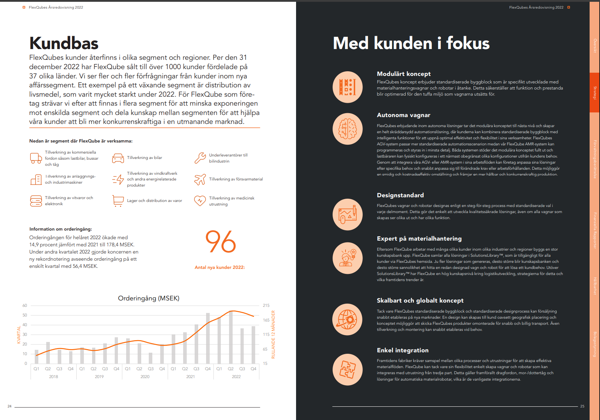

In [10]:
from google.colab import files
from PIL import Image

# Upload image
print("Upload your image:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load image
image = Image.open(image_path).convert("RGB")
print(f"Image loaded: {image.size[0]}x{image.size[1]}px")

# Display preview
preview = image.copy()
preview.thumbnail((600, 600))
display(preview)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


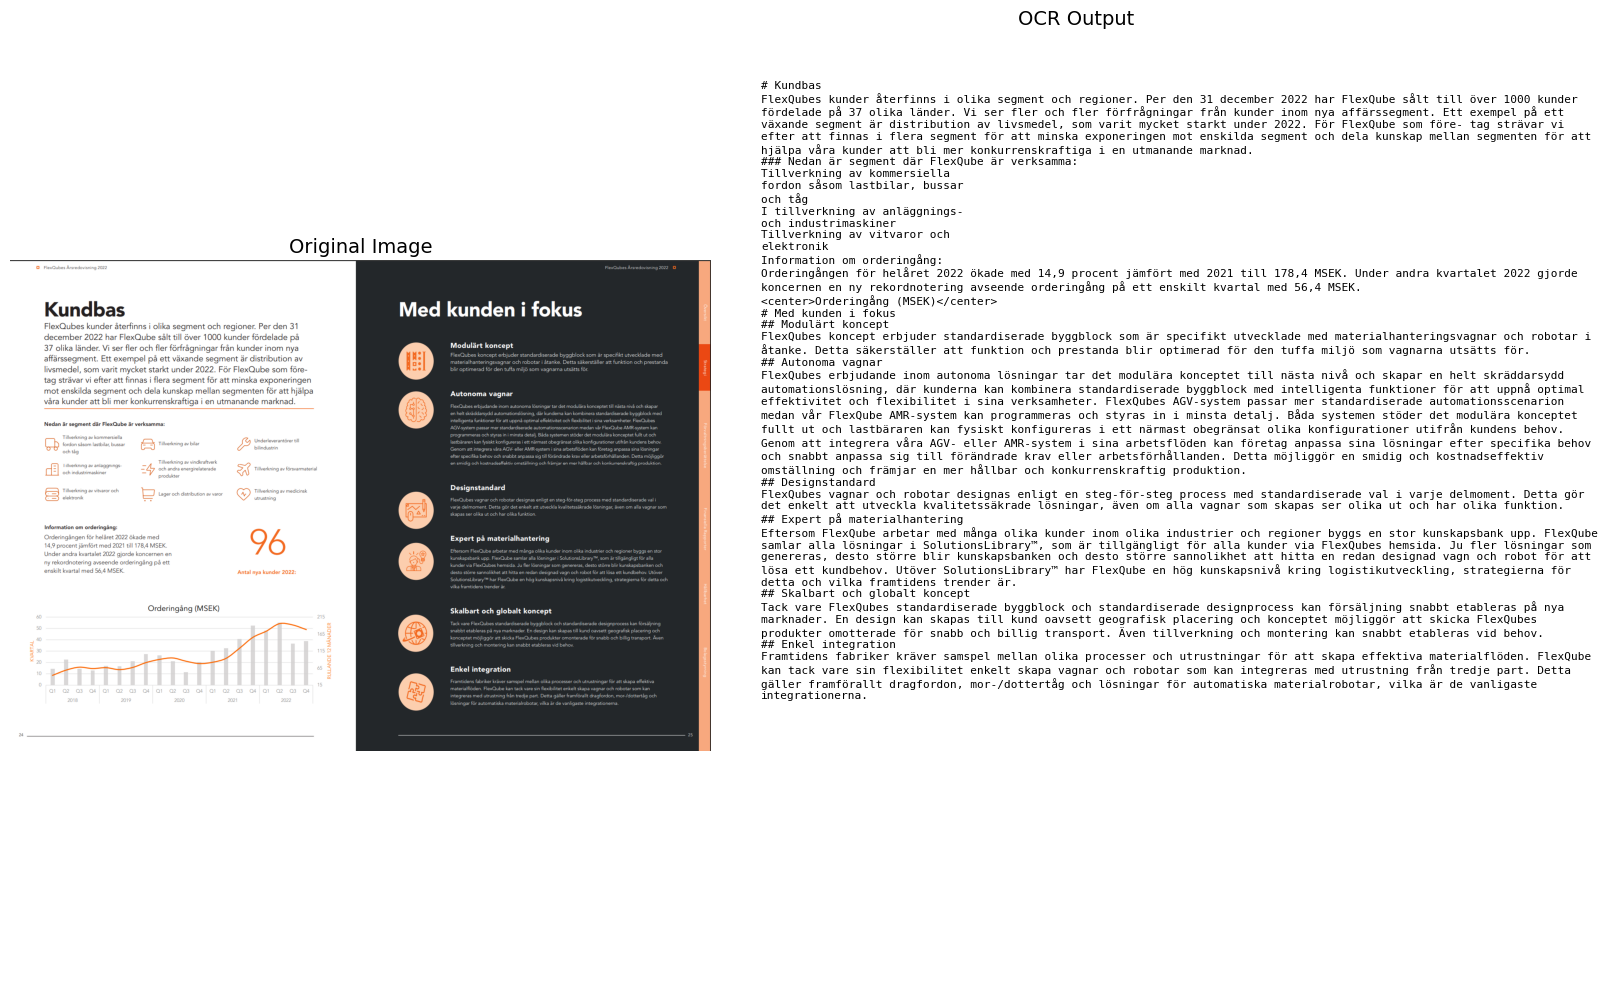

In [13]:
import matplotlib.pyplot as plt

# Run OCR
print("Running OCR...")
result = ocr_single_image(image)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Left: Image
axes[0].imshow(image)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis('off')

# Right: OCR result
axes[1].text(0.05, 0.95, result,
             transform=axes[1].transAxes,
             fontsize=8,
             verticalalignment='top',
             fontfamily='monospace',
             wrap=True)
axes[1].set_title("OCR Output", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nTotal chars: {len(result):,}")